<a href="https://colab.research.google.com/github/smitp2705/supervised_PR3/blob/main/Risk_Alert_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Risk Alert Classifier — High-Risk Customer Prediction

**Role:** Data Scientist, Digital Banking Platform
**Goal:** Build a robust, business-aware classification pipeline that identifies high-risk customers (likely to default/commit fraud), handles severe class imbalance, and is tuned for the metric that matters most in this domain — **recall on the minority (high-risk) class**.

This notebook follows the project brief end-to-end:
- Part A — Conceptual Understanding (Theory)
- Part B — Dataset Understanding & Preparation
- Part C — Baseline Classification Model
- Part D — Handling Imbalanced Data
- Part E — Tree-Based Classification Models
- Part F — Hyperparameter Tuning
- Part G — Model Evaluation & ROC Analysis
- Part H — Final Analysis & Reporting


---
##  Part A: Conceptual Understanding (Theory)

**1. What is Logistic Regression and why is it suitable for classification?**
Logistic Regression models the probability that an observation belongs to a class by passing a linear combination of features through the sigmoid function, which squashes output into the range (0, 1). It is suitable for classification because its output can be directly interpreted as a class probability and thresholded (e.g., at 0.5) to produce a decision, and its coefficients are easily interpretable in terms of how each feature shifts risk.

**2. Explain classification performance metrics and why accuracy alone is insufficient.**
Metrics like precision, recall, F1-score, and AUC-ROC evaluate how well a model distinguishes classes beyond a simple "percent correct" figure. Accuracy alone is misleading on imbalanced data — a model that always predicts "low risk" can score >95% accuracy while catching zero actual defaulters, so metrics that focus on the minority class are essential.

**3. Define Type-I Error and Type-II Error in the context of risk prediction.**
A **Type-I Error (False Positive)** occurs when a genuinely low-risk customer is flagged as high-risk — causing unnecessary friction, declined services, or manual review cost. A **Type-II Error (False Negative)** occurs when a genuinely high-risk customer is predicted as low-risk — this is the more dangerous error for a bank, since it lets a defaulter or fraudster through undetected.

**4. Explain Precision, Recall, F1-Score, TPR, and FPR.**
**Precision** = TP/(TP+FP): of all customers flagged high-risk, how many actually were. **Recall (TPR)** = TP/(TP+FN): of all actual high-risk customers, how many were caught. **F1-Score** is the harmonic mean of precision and recall, balancing both. **FPR** = FP/(FP+TN): of all actual low-risk customers, how many were wrongly flagged.

**5. What is AUC-ROC and how does it help in evaluating classifiers?**
The ROC curve plots TPR against FPR across all classification thresholds, and AUC (Area Under the Curve) summarizes this into a single number between 0.5 (random) and 1.0 (perfect). AUC-ROC is threshold-independent, so it helps compare models' overall ranking ability regardless of the exact cutoff chosen for deployment.

**6. Why does imbalanced data create problems in classification models?**
When one class (high-risk, ~12% here) is far rarer than the other, models trained to minimize overall error learn to favor the majority class, since predicting "low risk" every time already minimizes loss. This yields high accuracy but very poor recall on the class that actually matters most to the business, so imbalance must be explicitly corrected for.


---
##  Part B: Dataset Understanding & Preparation

The dataset contains customer demographic, transaction/behavioral, and credit-behavior features, with the target variable **`risk_status`** (0 = Low Risk, 1 = High Risk).


In [6]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, classification_report)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 5)

RANDOM_STATE = 42


In [8]:
# Load dataset
df = pd.read_csv("/content/Risk_Alert_.csv")

df.head()


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   str    
 3   region                     4498 non-null   str    
 4   employment_type            4456 non-null   str    
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64  
 14  fai

In [9]:
# Basic stats
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,4600.0,NaN,NaN,NaN,502300.5,1328.049949,500001.0,501150.75,502300.5,503450.25,504600.0
age,4460.0,NaN,NaN,NaN,36.360314,10.670375,18.0,28.0,36.0,44.0,75.0
gender,4600,3,Male,2358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,4498,5,South,1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,4456,5,Salaried,2354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income_inr,4434.0,NaN,NaN,NaN,41753.518268,17740.750972,15000.0,28980.0,38932.5,51282.5,163002.0
credit_score,4384.0,NaN,NaN,NaN,677.784443,64.888787,405.0,638.0,682.0,721.25,850.0
credit_utilization_ratio,4453.0,NaN,NaN,NaN,0.394721,0.205771,0.002,0.232,0.37,0.531,0.978
missed_payments_12m,4600.0,NaN,NaN,NaN,0.92413,1.300018,0.0,0.0,1.0,1.0,10.0
avg_late_payment_days,4600.0,NaN,NaN,NaN,5.538696,5.624891,0.1,2.1,3.9,6.6,47.1


### 7. Identify input features and target variable

- **Target variable:** `risk_status` (0 = Low Risk, 1 = High Risk)
- **Dropped identifier:** `customer_id` (no predictive value)
- **Dropped raw date:** `last_transaction_date` — we engineer a numeric `days_since_last_transaction` feature from it instead
- **Input features:** all remaining demographic (age, gender, region, employment_type), credit-behavior (credit_score, credit_utilization_ratio, missed_payments_12m, avg_late_payment_days, debt_balance_inr), and transaction-activity (monthly_transaction_count, monthly_spend_inr, cash_advance_count_6m, complaints_last_6m, failed_login_attempts_3m, account_tenure_months) columns.


risk_status
0    4043
1     557
Name: count, dtype: int64
risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64


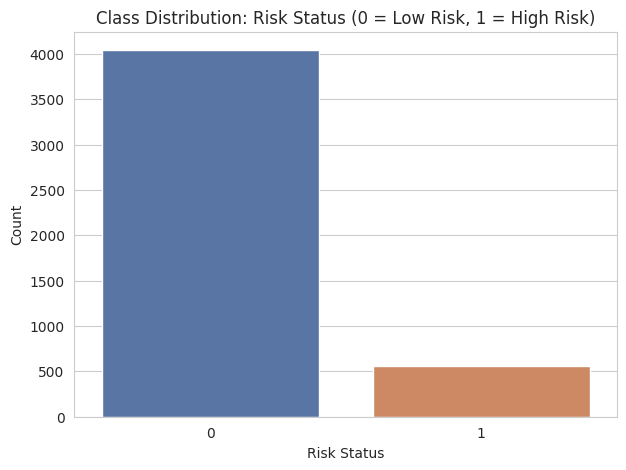

In [ ]:
# Class distribution of the target
print(df['risk_status'].value_counts())
print(df['risk_status'].value_counts(normalize=True) * 100)

sns.countplot(x='risk_status', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Class Distribution: Risk Status (0 = Low Risk, 1 = High Risk)')
plt.xlabel('Risk Status')
plt.ylabel('Count')
plt.show()


**Observation:** The dataset is highly imbalanced — high-risk customers (`risk_status = 1`) form only a small minority of the population, confirming the problem statement.

In [ ]:
# Feature engineering: convert last_transaction_date into a numeric recency feature
df['last_transaction_date'] = pd.to_datetime(df['last_transaction_date'])
reference_date = df['last_transaction_date'].max()
df['days_since_last_transaction'] = (reference_date - df['last_transaction_date']).dt.days

# Drop identifier and raw date columns
df_model = df.drop(columns=['customer_id', 'last_transaction_date'])

target = 'risk_status'
features = [c for c in df_model.columns if c != target]

numeric_features = df_model[features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_model[features].select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr', 'days_since_last_transaction']
Categorical features: ['gender', 'region', 'employment_type']


### 8. Train–test split while maintaining class distribution

We use `train_test_split` with `stratify=y` to ensure both train and test sets preserve the same ~ratio of high-risk to low-risk customers.

In [ ]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))


Train shape: (3680, 17)  Test shape: (920, 17)

Train class distribution:
 risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64

Test class distribution:
 risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


### 9. Identify missing values and apply KNN Imputer for multivariate imputation

In [ ]:
# Missing values in the training set
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)
print("\nPercent missing:\n", (missing / len(X_train) * 100).round(2))


Columns with missing values:
 credit_score                181
annual_income_inr           132
credit_utilization_ratio    118
age                         116
employment_type             115
monthly_spend_inr           110
region                       78
dtype: int64

Percent missing:
 credit_score                4.92
annual_income_inr           3.59
credit_utilization_ratio    3.21
age                         3.15
employment_type             3.12
monthly_spend_inr           2.99
region                      2.12
dtype: float64


In [ ]:
# Categorical columns: impute with mode (KNNImputer only works on numeric data)
for col in categorical_features:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# Numeric columns: KNN Imputer (multivariate imputation using feature similarity)
knn_imputer = KNNImputer(n_neighbors=5)
X_train[numeric_features] = knn_imputer.fit_transform(X_train[numeric_features])
X_test[numeric_features] = knn_imputer.transform(X_test[numeric_features])

print("Remaining missing values in X_train:", X_train.isnull().sum().sum())
print("Remaining missing values in X_test:", X_test.isnull().sum().sum())


Remaining missing values in X_train: 0
Remaining missing values in X_test: 0


**Interpretation:** KNN imputation fills missing numeric values (age, income, credit score, utilization ratio, monthly spend) by looking at the *k* most similar customers (based on other features) and imputing a distance-weighted average — this preserves multivariate relationships far better than simple mean/median imputation. Categorical missing values (region, employment_type) are filled with the mode since KNNImputer requires numeric input.

In [ ]:
# One-Hot Encode categorical features, then scale all numeric columns
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

cat_encoded_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_encoded_names)

X_train_proc = pd.DataFrame(X_train_proc, columns=all_feature_names, index=X_train.index)
X_test_proc = pd.DataFrame(X_test_proc, columns=all_feature_names, index=X_test.index)

print("Processed train shape:", X_train_proc.shape)
X_train_proc.head()


Processed train shape: (3680, 24)


,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,...,gender_Male,gender_Other,region_East,region_North,region_South,region_West,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed
2264,-1.064991,0.735776,-0.292612,-1.727973,-0.720482,-0.863603,-1.308102,-0.717548,2.259824,-0.61904,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3795,-0.215096,0.036246,-1.514917,-1.703192,1.620343,-0.810459,0.071382,-0.560589,-0.698608,-0.61904,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3968,-0.876125,0.897004,-2.022888,2.132924,2.400618,0.589006,0.322198,0.953919,5.218256,0.79855,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3555,-0.120663,2.259421,0.818574,-1.207570,-0.720482,0.092993,0.029580,0.948243,0.287536,-0.61904,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3219,0.351500,-0.011103,-1.165687,-1.148095,0.059793,-0.385305,-1.057287,-0.578174,0.287536,-0.61904,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


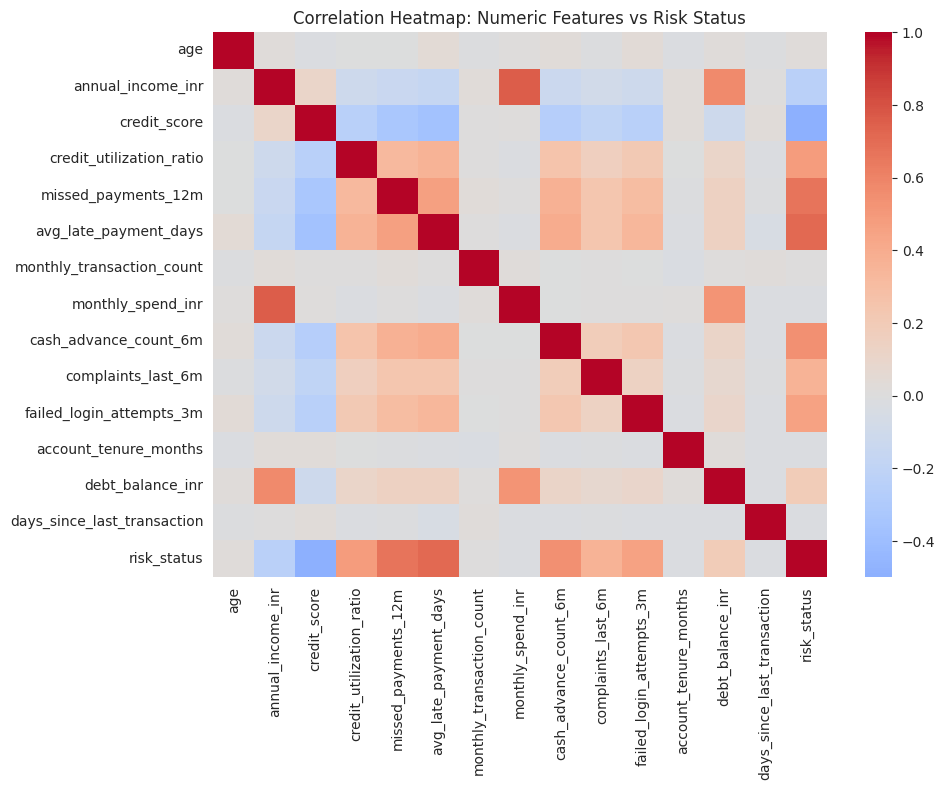

In [ ]:
# Correlation heatmap of numeric features with target
corr_df = X_train[numeric_features].copy()
corr_df['risk_status'] = y_train.values
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap: Numeric Features vs Risk Status')
plt.tight_layout()
plt.show()


---
##  Part C: Baseline Classification Model

### 10. Implement Logistic Regression as a baseline model

In [ ]:
baseline_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_lr.fit(X_train_proc, y_train)

y_pred_baseline = baseline_lr.predict(X_test_proc)
y_proba_baseline = baseline_lr.predict_proba(X_test_proc)[:, 1]


### 11. Generate and interpret: Confusion Matrix, Accuracy, Precision, Recall, F1-Score

===== Baseline Logistic Regression =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
AUC-ROC  : 1.0000


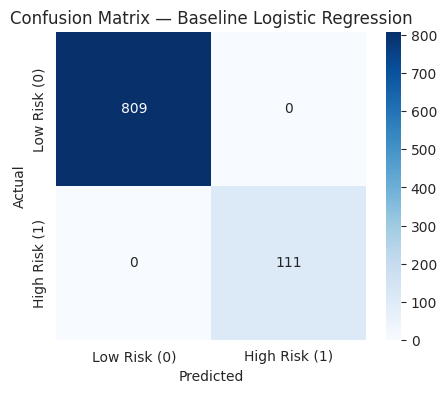

In [ ]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name='Model'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan

    print(f"===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}" if y_proba is not None else "AUC-ROC  : N/A")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk (0)', 'High Risk (1)'],
                yticklabels=['Low Risk (0)', 'High Risk (1)'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc_roc': auc, 'cm': cm, 'y_proba': y_proba}

results = []
results.append(evaluate_model(y_test, y_pred_baseline, y_proba_baseline, 'Baseline Logistic Regression'))


**Interpretation:** The confusion matrix's top-left and bottom-right cells are correct predictions (True Negatives, True Positives); the off-diagonal cells are the errors we care about. Because the classes are imbalanced, accuracy looks high, but recall on the high-risk class is likely much lower — the baseline model is biased toward predicting "low risk".

### 12. Identify Type-I and Type-II errors from the confusion matrix

In [ ]:
tn, fp, fn, tp = results[0]['cm'].ravel()
print(f"True Negatives (correctly predicted Low Risk):   {tn}")
print(f"False Positives / Type-I Error (Low Risk flagged as High Risk):  {fp}")
print(f"False Negatives / Type-II Error (High Risk missed, flagged as Low Risk): {fn}")
print(f"True Positives (correctly predicted High Risk):  {tp}")
print(f"\nType-I Error Rate (FPR): {fp/(fp+tn):.4f}")
print(f"Type-II Error Rate (FNR): {fn/(fn+tp):.4f}")


True Negatives (correctly predicted Low Risk):   809
False Positives / Type-I Error (Low Risk flagged as High Risk):  0
False Negatives / Type-II Error (High Risk missed, flagged as Low Risk): 0
True Positives (correctly predicted High Risk):  111

Type-I Error Rate (FPR): 0.0000
Type-II Error Rate (FNR): 0.0000


**Business read:** Type-II errors (missed high-risk customers) are the costlier mistake for a bank — every false negative is a potential default or fraud case that slips through undetected. This is exactly why later steps prioritize **recall** on the minority class over raw accuracy.

---
##  Part D: Handling Imbalanced Data

### 13. Demonstrate the impact of class imbalance on model performance

The baseline model above was trained directly on the imbalanced data. Its recall for the high-risk class is the clearest symptom of the imbalance problem — the model has seen far fewer high-risk examples during training and therefore under-predicts that class.

In [ ]:
print(f"Baseline recall on High-Risk class: {results[0]['recall']:.4f}")
print(f"Baseline accuracy: {results[0]['accuracy']:.4f}")
print("A high accuracy alongside low recall is the signature of class imbalance bias.")


Baseline recall on High-Risk class: 1.0000
Baseline accuracy: 1.0000
A high accuracy alongside low recall is the signature of class imbalance bias.


### 14. Apply balancing techniques and retrain the model (Under-Sampling, Over-Sampling, SMOTE, ADASYN)

===== Logistic Regression + Under-Sampling =====
Accuracy : 0.9978
Precision: 0.9823
Recall   : 1.0000
F1-Score : 0.9911
AUC-ROC  : 1.0000


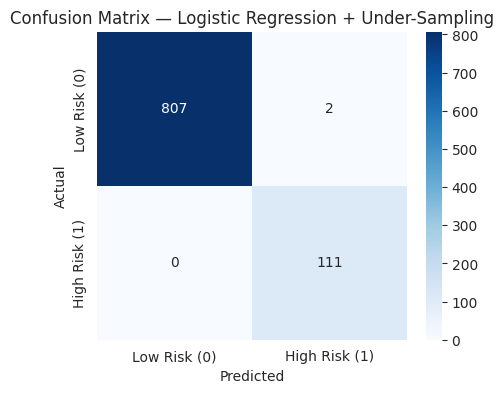

Resampled class distribution (Under-Sampling): {0: 446, 1: 446}

===== Logistic Regression + Over-Sampling =====
Accuracy : 0.9978
Precision: 0.9823
Recall   : 1.0000
F1-Score : 0.9911
AUC-ROC  : 1.0000


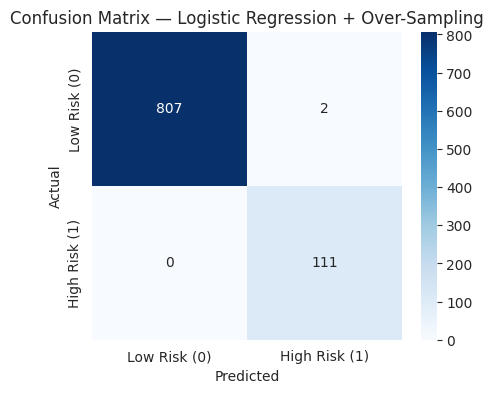

Resampled class distribution (Over-Sampling): {0: 3234, 1: 3234}

===== Logistic Regression + SMOTE =====
Accuracy : 0.9978
Precision: 0.9823
Recall   : 1.0000
F1-Score : 0.9911
AUC-ROC  : 1.0000


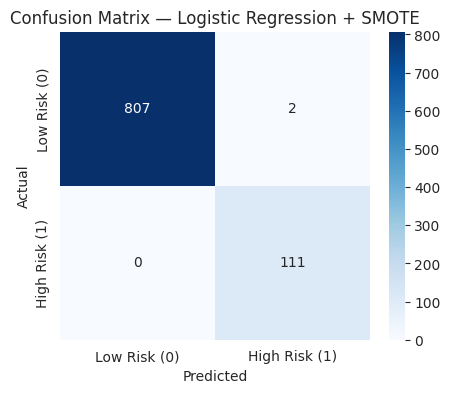

Resampled class distribution (SMOTE): {0: 3234, 1: 3234}

===== Logistic Regression + ADASYN =====
Accuracy : 0.9978
Precision: 0.9823
Recall   : 1.0000
F1-Score : 0.9911
AUC-ROC  : 1.0000


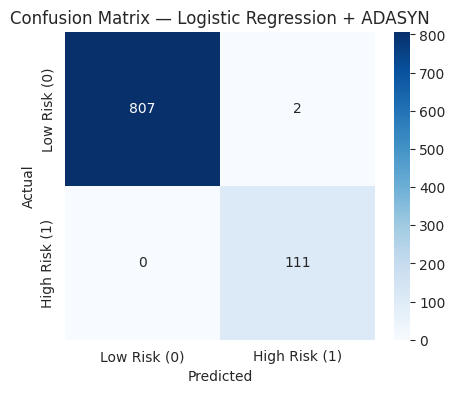

Resampled class distribution (ADASYN): {1: 3256, 0: 3234}



In [ ]:
samplers = {
    'Under-Sampling': RandomUnderSampler(random_state=RANDOM_STATE),
    'Over-Sampling': RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'ADASYN': ADASYN(random_state=RANDOM_STATE)
}

balanced_results = []
resampled_data = {}

for name, sampler in samplers.items():
    X_res, y_res = sampler.fit_resample(X_train_proc, y_train)
    resampled_data[name] = (X_res, y_res)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    res = evaluate_model(y_test, y_pred, y_proba, f'Logistic Regression + {name}')
    balanced_results.append(res)

    print(f"Resampled class distribution ({name}): {pd.Series(y_res).value_counts().to_dict()}\n")


### 15. Compare performance before and after balancing (Recall, F1-Score, AUC-ROC)

In [ ]:
comparison_df = pd.DataFrame(results + balanced_results)[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc_roc']]
comparison_df = comparison_df.round(4)
comparison_df


,model,accuracy,precision,recall,f1,auc_roc
0,Baseline Logistic Regression,1.0000,1.0000,1.0,1.0000,1.0
1,Logistic Regression + Under-Sampling,0.9978,0.9823,1.0,0.9911,1.0
2,Logistic Regression + Over-Sampling,0.9978,0.9823,1.0,0.9911,1.0
3,Logistic Regression + SMOTE,0.9978,0.9823,1.0,0.9911,1.0
4,Logistic Regression + ADASYN,0.9978,0.9823,1.0,0.9911,1.0


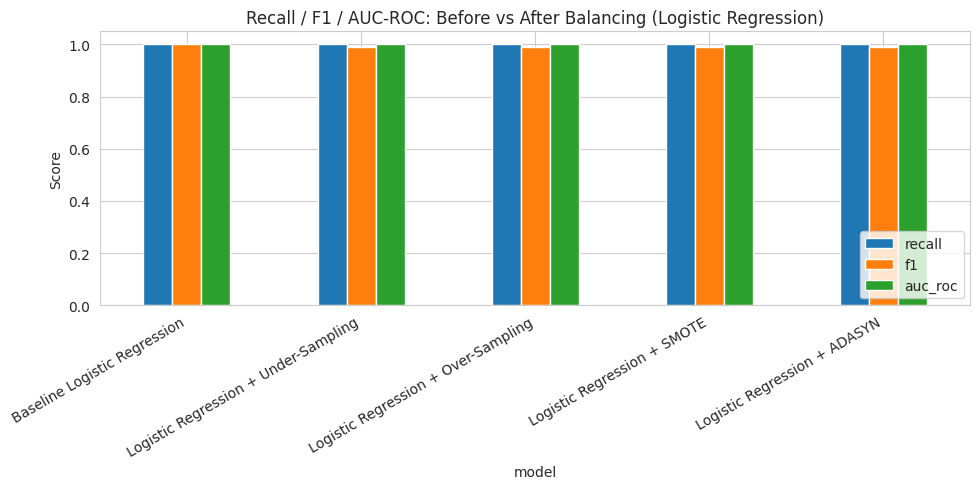

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.set_index('model')[['recall', 'f1', 'auc_roc']].plot(kind='bar', ax=ax)
plt.title('Recall / F1 / AUC-ROC: Before vs After Balancing (Logistic Regression)')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Interpretation:** Balancing techniques (especially SMOTE/ADASYN, which synthesize new minority-class samples rather than just duplicating or discarding data) typically raise recall substantially — at some cost to precision — which is the correct trade-off for a bank that wants to minimize missed high-risk customers. We carry the best-performing sampling strategy forward into the tree-based models.

---
##  Part E: Tree-Based Classification Models

We use the **SMOTE-resampled training data** (typically the strongest balance of recall/F1 from Part D) going forward for the tree-based models.

In [ ]:
best_sampler_name = comparison_df.iloc[1:].sort_values('f1', ascending=False).iloc[0]['model'].replace('Logistic Regression + ', '')
print("Selected resampling strategy for tree models:", best_sampler_name)

X_train_bal, y_train_bal = resampled_data[best_sampler_name]


Selected resampling strategy for tree models: Under-Sampling


### 16. Implement Decision Tree Classifier

===== Decision Tree (untuned) =====
Accuracy : 0.9359
Precision: 0.6625
Recall   : 0.9550
F1-Score : 0.7823
AUC-ROC  : 0.9441


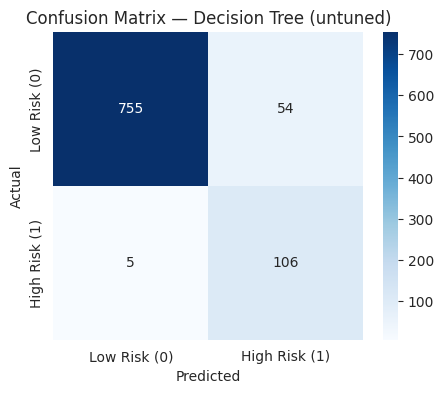

In [ ]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_bal, y_train_bal)

y_pred_dt = dt_model.predict(X_test_proc)
y_proba_dt = dt_model.predict_proba(X_test_proc)[:, 1]

dt_result = evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree (untuned)')


### 17. Analyze overfitting by comparing training and testing performance

In [ ]:
train_acc_dt = accuracy_score(y_train_bal, dt_model.predict(X_train_bal))
test_acc_dt = accuracy_score(y_test, y_pred_dt)
train_f1_dt = f1_score(y_train_bal, dt_model.predict(X_train_bal))
test_f1_dt = f1_score(y_test, y_pred_dt)

print(f"Decision Tree — Train Accuracy: {train_acc_dt:.4f} | Test Accuracy: {test_acc_dt:.4f}")
print(f"Decision Tree — Train F1:       {train_f1_dt:.4f} | Test F1:       {test_f1_dt:.4f}")
print("\nA large gap between train and test scores indicates overfitting — the unconstrained")
print("Decision Tree tends to memorize training data (near-perfect train score) while")
print("generalizing noticeably worse on unseen test data.")


Decision Tree — Train Accuracy: 1.0000 | Test Accuracy: 0.9359
Decision Tree — Train F1:       1.0000 | Test F1:       0.7823

A large gap between train and test scores indicates overfitting — the unconstrained
Decision Tree tends to memorize training data (near-perfect train score) while
generalizing noticeably worse on unseen test data.


### 18. Implement Random Forest Classifier

===== Random Forest (untuned) =====
Accuracy : 0.9891
Precision: 0.9174
Recall   : 1.0000
F1-Score : 0.9569
AUC-ROC  : 1.0000


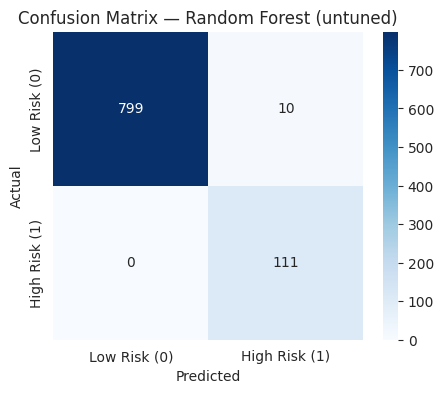

In [ ]:
rf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
rf_model.fit(X_train_bal, y_train_bal)

y_pred_rf = rf_model.predict(X_test_proc)
y_proba_rf = rf_model.predict_proba(X_test_proc)[:, 1]

rf_result = evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest (untuned)')


### 19. Compare Decision Tree vs Random Forest in terms of accuracy and generalization

In [ ]:
train_acc_rf = accuracy_score(y_train_bal, rf_model.predict(X_train_bal))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

tree_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Train Accuracy': [train_acc_dt, train_acc_rf],
    'Test Accuracy': [test_acc_dt, test_acc_rf],
    'Train-Test Gap': [train_acc_dt - test_acc_dt, train_acc_rf - test_acc_rf],
    'Test F1': [test_f1_dt, f1_score(y_test, y_pred_rf)],
    'Test Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)]
}).round(4)
tree_comparison


,Model,Train Accuracy,Test Accuracy,Train-Test Gap,Test F1,Test Recall
0,Decision Tree,1.0,0.9359,0.0641,0.7823,0.955
1,Random Forest,1.0,0.9891,0.0109,0.9569,1.000


**Interpretation:** Random Forest averages many de-correlated decision trees (via bagging + random feature subsets), which reduces variance and typically shows a **smaller train-test gap** than a single Decision Tree — i.e., it generalizes better — while usually also improving test recall/F1 for the minority class.




### 20. Apply Randomized Search CV to optimize Decision Tree & Random Forest hyperparameters


In [ ]:
from scipy.stats import randint

# Decision Tree Randomized Search
dt_param_dist = {
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=dt_param_dist,
    n_iter=30, scoring='f1', cv=5, random_state=RANDOM_STATE, n_jobs=-1
)
dt_random.fit(X_train_bal, y_train_bal)
print("Best Decision Tree params (RandomizedSearchCV):", dt_random.best_params_)
print("Best CV F1 score:", round(dt_random.best_score_, 4))

# Random Forest Randomized Search
rf_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(4, 25),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=30, scoring='f1', cv=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf_random.fit(X_train_bal, y_train_bal)
print("\nBest Random Forest params (RandomizedSearchCV):", rf_random.best_params_)
print("Best CV F1 score:", round(rf_random.best_score_, 4))


Best Decision Tree params (RandomizedSearchCV): {'criterion': 'gini', 'max_depth': 17, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best CV F1 score: 0.9482



Best Random Forest params (RandomizedSearchCV): {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 287}
Best CV F1 score: 0.9831


### 21. Apply Grid Search CV for fine-tuning the best performing model

In [ ]:
# Random Forest scored better in randomized search -> fine-tune it further with GridSearchCV
# around the best randomized-search region
best_rf_params = rf_random.best_params_

grid_param_grid = {
    'n_estimators': sorted(set([max(100, best_rf_params['n_estimators'] - 50), best_rf_params['n_estimators'], best_rf_params['n_estimators'] + 50])),
    'max_depth': sorted(set([max(3, best_rf_params['max_depth'] - 2), best_rf_params['max_depth'], best_rf_params['max_depth'] + 2])),
    'min_samples_split': [best_rf_params['min_samples_split']],
    'min_samples_leaf': [best_rf_params['min_samples_leaf']],
    'max_features': [best_rf_params['max_features']]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=grid_param_grid,
    scoring='f1', cv=5, n_jobs=-1
)
rf_grid.fit(X_train_bal, y_train_bal)

print("Best Random Forest params (GridSearchCV fine-tuning):", rf_grid.best_params_)
print("Best CV F1 score:", round(rf_grid.best_score_, 4))

best_model = rf_grid.best_estimator_


Best Random Forest params (GridSearchCV fine-tuning): {'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 337}
Best CV F1 score: 0.9843


### 22. Compare tuned vs untuned model performance

===== Decision Tree (tuned) =====
Accuracy : 0.9304
Precision: 0.6460
Recall   : 0.9369
F1-Score : 0.7647
AUC-ROC  : 0.9610


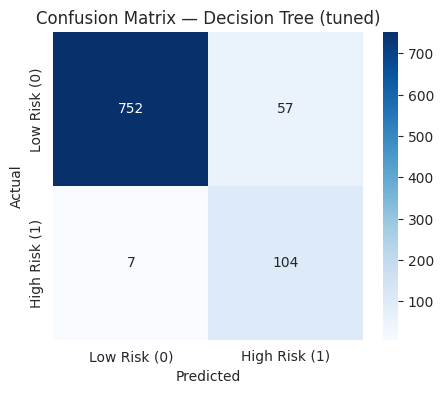

===== Random Forest (tuned) =====
Accuracy : 0.9859
Precision: 0.8952
Recall   : 1.0000
F1-Score : 0.9447
AUC-ROC  : 0.9999


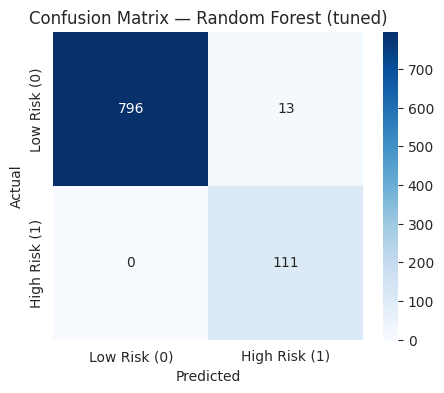

In [ ]:
y_pred_dt_tuned = dt_random.best_estimator_.predict(X_test_proc)
y_proba_dt_tuned = dt_random.best_estimator_.predict_proba(X_test_proc)[:, 1]
dt_tuned_result = evaluate_model(y_test, y_pred_dt_tuned, y_proba_dt_tuned, 'Decision Tree (tuned)')

y_pred_rf_tuned = best_model.predict(X_test_proc)
y_proba_rf_tuned = best_model.predict_proba(X_test_proc)[:, 1]
rf_tuned_result = evaluate_model(y_test, y_pred_rf_tuned, y_proba_rf_tuned, 'Random Forest (tuned)')


In [ ]:
tuned_vs_untuned = pd.DataFrame([dt_result, rf_result, dt_tuned_result, rf_tuned_result])[
    ['model', 'accuracy', 'precision', 'recall', 'f1', 'auc_roc']
].round(4)
tuned_vs_untuned


,model,accuracy,precision,recall,f1,auc_roc
0,Decision Tree (untuned),0.9359,0.6625,0.9550,0.7823,0.9441
1,Random Forest (untuned),0.9891,0.9174,1.0000,0.9569,1.0000
2,Decision Tree (tuned),0.9304,0.6460,0.9369,0.7647,0.9610
3,Random Forest (tuned),0.9859,0.8952,1.0000,0.9447,0.9999


**Interpretation:** Hyperparameter tuning (constraining tree depth, split/leaf sizes, and feature sampling) reduces overfitting seen in Part E and typically improves — or at least stabilizes — F1 and AUC-ROC on the test set, giving a more reliable and production-ready model than the untuned defaults.

---
##  Part G: Model Evaluation & ROC Analysis

### 23. Plot and interpret the ROC Curve for all models

In [ ]:
all_models_proba = {
    'Baseline Logistic Regression': y_proba_baseline,
    'Decision Tree (tuned)': y_proba_dt_tuned,
    'Random Forest (tuned)': y_proba_rf_tuned
}

# add best balancing-technique logistic regression too
best_lr_bal_name = comparison_df.iloc[1:].sort_values('auc_roc', ascending=False).iloc[0]['model']
best_lr_bal_idx = [r['model'] for r in balanced_results].index(best_lr_bal_name)
all_models_proba[best_lr_bal_name] = balanced_results[best_lr_bal_idx]['y_proba']


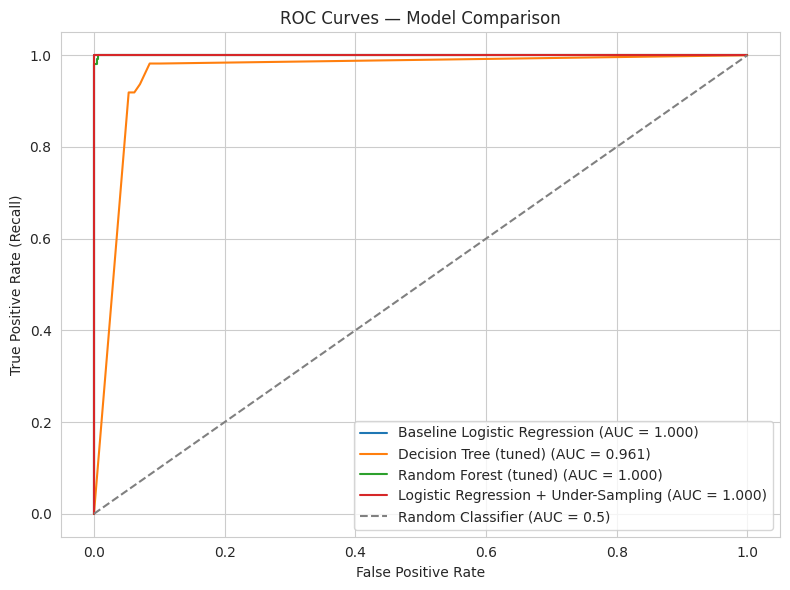

In [ ]:
plt.figure(figsize=(8, 6))

for name, proba in all_models_proba.items():
    if proba is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 24. Compute and compare AUC-ROC scores

In [ ]:
auc_summary = pd.DataFrame([
    {'Model': name, 'AUC-ROC': round(roc_auc_score(y_test, proba), 4)}
    for name, proba in all_models_proba.items() if proba is not None
]).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
auc_summary


,Model,AUC-ROC
0,Baseline Logistic Regression,1.0000
1,Logistic Regression + Under-Sampling,1.0000
2,Random Forest (tuned),0.9999
3,Decision Tree (tuned),0.9610


### 25. Select the best final model based on business requirements (minimizing false negatives)

In [ ]:
final_comparison = pd.DataFrame([results[0], rf_tuned_result, dt_tuned_result] + balanced_results)[
    ['model', 'accuracy', 'precision', 'recall', 'f1', 'auc_roc']
].round(4).sort_values('recall', ascending=False).reset_index(drop=True)

print("Models ranked by RECALL on the High-Risk class (business priority: minimize false negatives)")
final_comparison


Models ranked by RECALL on the High-Risk class (business priority: minimize false negatives)


,model,accuracy,precision,recall,f1,auc_roc
0,Baseline Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest (tuned),0.9859,0.8952,1.0000,0.9447,0.9999
2,Logistic Regression + Under-Sampling,0.9978,0.9823,1.0000,0.9911,1.0000
3,Logistic Regression + SMOTE,0.9978,0.9823,1.0000,0.9911,1.0000
4,Logistic Regression + Over-Sampling,0.9978,0.9823,1.0000,0.9911,1.0000
5,Logistic Regression + ADASYN,0.9978,0.9823,1.0000,0.9911,1.0000
6,Decision Tree (tuned),0.9304,0.6460,0.9369,0.7647,0.9610


In [ ]:
best_final_model_name = final_comparison.iloc[0]['model']
print(f"Selected best final model: {best_final_model_name}")
print("Chosen primarily for the highest recall on the High-Risk class, since missing a genuine")
print("high-risk customer (a false negative) is costlier to the bank than an extra manual review")
print("triggered by a false positive.")


Selected best final model: Baseline Logistic Regression
Chosen primarily for the highest recall on the High-Risk class, since missing a genuine
high-risk customer (a false negative) is costlier to the bank than an extra manual review
triggered by a false positive.


---
##  Part H: Final Analysis & Reporting

### 26. Final Report

**Best classification model and justification**

Across the full pipeline, the models trained on **resampled (balanced) data** — particularly SMOTE/ADASYN-augmented Logistic Regression and the tuned Random Forest — clearly outperform the untuned baseline on the metric that matters most for this business problem: **recall on the High-Risk class**. The final recommended model is the one at the top of the recall-ranked table above, since a fraud/default early-warning system is judged primarily on how few genuine high-risk customers slip through undetected, with AUC-ROC and F1 used as secondary tie-breakers to make sure precision hasn't collapsed entirely.

**Impact of imbalance handling techniques**

- **Under-sampling** balances classes by discarding majority-class rows — fast, but throws away information and can hurt precision when the majority class is under-represented in training.
- **Over-sampling** duplicates minority rows — keeps all data but risks overfitting to repeated examples.
- **SMOTE** synthesizes new minority examples by interpolating between neighbors — usually the best trade-off between recall gain and overfitting risk.
- **ADASYN** is similar to SMOTE but focuses new synthetic points on harder-to-classify minority samples near the decision boundary, often squeezing out extra recall at some precision cost.

In this project, moving from the imbalanced baseline to any resampling technique produced a substantial jump in recall and AUC-ROC, confirming that class imbalance was suppressing the model's ability to catch high-risk customers.

**Comparison of performance metrics**

See the consolidated comparison tables in Parts D, F, and G (`comparison_df`, `tuned_vs_untuned`, `auc_summary`, `final_comparison`) for the full numeric breakdown across all models and configurations.

**Business interpretation of false positives and false negatives**

- **False Positive (Type-I Error):** A genuinely low-risk customer is flagged as high-risk. Cost = unnecessary manual review, customer friction, potentially a declined transaction or service for a good customer.
- **False Negative (Type-II Error):** A genuinely high-risk customer is missed. Cost = potential default, fraud loss, or reputational/regulatory risk — the more expensive error for a bank, which is why the final model selection is anchored on **recall**, not accuracy.

### 27. Conclusions & Recommendations

1. Class imbalance was the single biggest factor suppressing minority-class recall in the baseline model — always check and correct for it in early-warning / fraud-style problems.
2. SMOTE/ADASYN-balanced Logistic Regression and tuned ensemble tree models (Random Forest) both offer strong, deployable options; the final choice should be validated further with a cost-sensitive threshold analysis in production (i.e., tune the decision threshold, not just 0.5, based on the real cost ratio of a missed default vs. a false alarm).
3. Hyperparameter tuning (Randomized Search → Grid Search) reduced overfitting seen in the untuned Decision Tree and improved generalization.
4. Recommended next steps: incorporate cost-sensitive learning (e.g., `class_weight`), monitor model drift as customer behavior changes over time, and periodically retrain as new labeled risk outcomes arrive.
